Rolex Reference Number 價格分析系統

Step 1: 載入資料
總資料筆數: 78974
不重複的 Reference Number: 4590

Step 2: 輸入查詢資訊

查詢 Ref: 116610LN
賣家報價: $15,000

Step 3: 分析同款手錶市場資料
✅ 找到 430 筆相同 Reference Number 的資料

Step 4: 價格統計分析
----------------------------------------
平均價格: $15,185
中位數價格: $14,694
標準差: $2,504
最低價: $8,000
最高價: $27,976
第一四分位數 (25%): $13,778
第三四分位數 (75%): $16,147

Step 5: 賣家價格評估
----------------------------------------
賣家報價: $15,000
市場百分位: 54.0% (有 54.0% 的同款錶比這便宜)
vs 平均價: -185 (-1.2%)
vs 中位數: +306 (+2.1%)

📊 評估結果:
評級: 合理價格 (低於平均)
評分: 65/100
建議: 接近市場價，可以考慮

Step 6: 條件細分分析
----------------------------------------

各條件價格分析:
            count     mean   median      min      max
condition                                            
New          31.0  16905.0  16202.0  12795.0  27146.0
Unworn       45.0  17663.0  16882.0  13204.0  26993.0
Very good   299.0  14735.0  14522.0   8000.0  27976.0
Good         47.0  14835.0  14279.0  10952.0  23841.0
Fair          7.0  13556.0  13200.0  13078.0  14500.0
Poor 

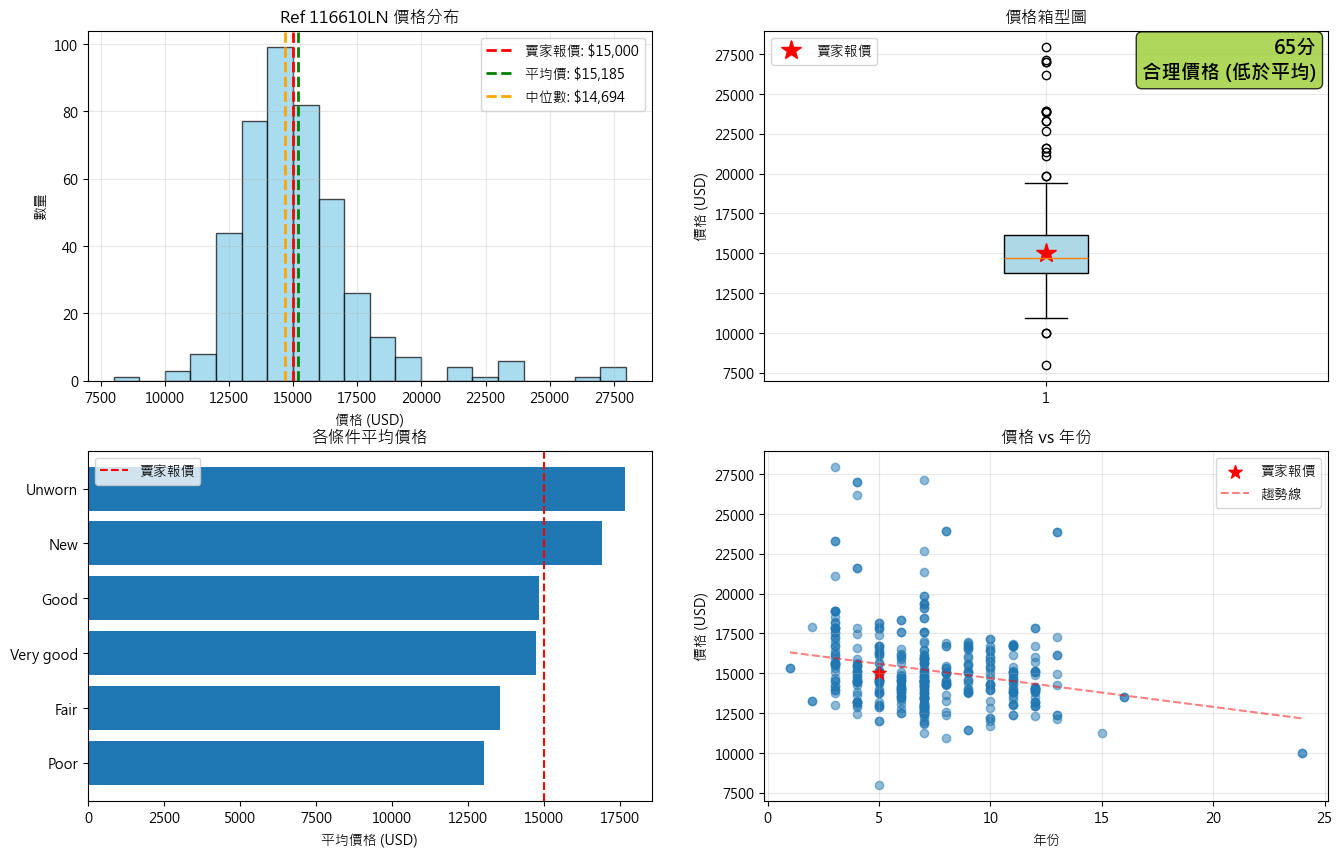

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib
from scipy import stats


# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 繁體中文字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題
# =====================================
# Step 1: 載入資料
# =====================================
print("="*60)
print("Rolex Reference Number 價格分析系統")
print("="*60)

print("\nStep 1: 載入資料")
df= pd.read_csv("../data/data_clean.csv",index_col=0)
print(f"總資料筆數: {len(df)}")
print(f"不重複的 Reference Number: {df['reference number'].nunique()}")

# =====================================
# Step 2: 輸入要查詢的 Reference Number
# =====================================
print("\nStep 2: 輸入查詢資訊")

# 使用者輸入
target_ref = input("請輸入 Reference Number (例如: 116610LN): ")
seller_price = float(input("請輸入賣家報價 (USD): "))
watch_age= float(input("請輸入手錶表齡: "))

print(f"\n查詢 Ref: {target_ref}")
print(f"賣家報價: ${seller_price:,.0f}")

# =====================================
# Step 3: 篩選相同 Reference Number 的資料
# =====================================
print("\nStep 3: 分析同款手錶市場資料")

# 篩選相同 ref 的資料
same_ref = df[df['reference number'] == target_ref].copy()

if len(same_ref) == 0:
    print(f"❌ 找不到 Reference Number: {target_ref} 的資料")
    print("建議檢查輸入是否正確，或使用相近的型號")
    
    # 顯示可能的相似 ref
    possible_refs = df['reference number'].value_counts().head(10)
    print("\n最常見的 Reference Numbers:")
    for ref, count in possible_refs.items():
        print(f"  {ref}: {count} 筆資料")
else:
    print(f"✅ 找到 {len(same_ref)} 筆相同 Reference Number 的資料")
    
    # =====================================
    # Step 4: 基礎統計分析
    # =====================================
    print("\nStep 4: 價格統計分析")
    print("-"*40)
    
    # 價格統計
    price_mean = same_ref['price'].mean()
    price_median = same_ref['price'].median()
    price_std = same_ref['price'].std()
    price_min = same_ref['price'].min()
    price_max = same_ref['price'].max()
    price_q1 = same_ref['price'].quantile(0.25)
    price_q3 = same_ref['price'].quantile(0.75)
    
    print(f"平均價格: ${price_mean:,.0f}")
    print(f"中位數價格: ${price_median:,.0f}")
    print(f"標準差: ${price_std:,.0f}")
    print(f"最低價: ${price_min:,.0f}")
    print(f"最高價: ${price_max:,.0f}")
    print(f"第一四分位數 (25%): ${price_q1:,.0f}")
    print(f"第三四分位數 (75%): ${price_q3:,.0f}")
    
    # =====================================
    # Step 5: 賣家價格評估
    # =====================================
    print("\nStep 5: 賣家價格評估")
    print("-"*40)
    
    # 計算賣家價格的位置
    percentile = (same_ref['price'] < seller_price).mean() * 100
    diff_from_mean = seller_price - price_mean
    diff_from_median = seller_price - price_median
    diff_pct_mean = (diff_from_mean / price_mean) * 100
    diff_pct_median = (diff_from_median / price_median) * 100
    
    print(f"賣家報價: ${seller_price:,.0f}")
    print(f"市場百分位: {percentile:.1f}% (有 {percentile:.1f}% 的同款錶比這便宜)")
    print(f"vs 平均價: {diff_from_mean:+,.0f} ({diff_pct_mean:+.1f}%)")
    print(f"vs 中位數: {diff_from_median:+,.0f} ({diff_pct_median:+.1f}%)")
    
    # 評級系統
    if seller_price < price_q1:
        rating = "極佳價格 (前25%最低價)"
        advice = "強烈建議購買！價格在市場最低的25%"
        score = 95
        color = 'darkgreen'
    elif seller_price < price_median:
        rating = "好價格 (低於中位數)"
        advice = "價格合理偏低，值得購買"
        score = 80
        color = 'green'
    elif seller_price < price_mean:
        rating = "合理價格 (低於平均)"
        advice = "接近市場價，可以考慮"
        score = 65
        color = 'yellowgreen'
    elif seller_price < price_q3:
        rating = "市場價 (高於平均但仍合理)"
        advice = "略高於平均，建議小幅議價"
        score = 50
        color = 'orange'
    else:
        rating = "偏貴 (前25%最高價)"
        advice = "價格偏高，建議議價或觀望"
        score = 30
        color = 'red'
    
    print(f"\n📊 評估結果:")
    print(f"評級: {rating}")
    print(f"評分: {score}/100")
    print(f"建議: {advice}")
    
    # =====================================
    # Step 6: 根據條件細分分析
    # =====================================
    print("\nStep 6: 條件細分分析")
    print("-"*40)
    
    # 按條件分組
    if 'condition' in same_ref.columns:
        condition_analysis = same_ref.groupby('condition', observed=False)['price'].agg([
            'count', 'mean', 'median', 'min', 'max'
        ]).round(0)
        print("\n各條件價格分析:")
        order = ['New', 'Unworn', 'Very good', 'Good', 'Fair', 'Poor', 'Incomplete']
        condition_analysis = condition_analysis.reindex(order)
        print(condition_analysis)
    
    # 按配件分組
    if 'full_set' in same_ref.columns:
        print("\n配件完整度影響:")
        full_set_yes = same_ref[same_ref['full_set'] == 1]['price'].mean()
        full_set_no = same_ref[same_ref['full_set'] == 0]['price'].mean()
        if not pd.isna(full_set_yes) and not pd.isna(full_set_no):
            print(f"Full Set: ${full_set_yes:,.0f}")
            print(f"Not Full Set: ${full_set_no:,.0f}")
            print(f"差價: ${full_set_yes - full_set_no:,.0f}")
    
    # 按年份分組
    if 'age' in same_ref.columns:
        print("\n不同年份價格趨勢:")
        age_groups = pd.cut(same_ref['age'], bins=[0, 2, 5, 10, 20, 100], 
                           labels=['<2年', '2-5年', '5-10年', '10-20年', '>20年'])
        age_analysis = same_ref.groupby(age_groups, observed=False)['price'].agg(['mean', 'count'])
        print(age_analysis.round(0))
    
    # =====================================
    # Step 7: 找出最相似的5筆交易
    # =====================================
    print("\nStep 7: 最相似的交易記錄")
    print("-"*40)
    
    # 計算價格差異並排序
    same_ref['price_diff'] = abs(same_ref['price'] - seller_price)
    similar_trades = same_ref.nsmallest(5, 'price_diff')
    
    print("最接近賣家報價的5筆交易:")
    for idx, (_, row) in enumerate(similar_trades.iterrows(), 1):
        print(f"\n{idx}. 價格: ${row['price']:,.0f} (差異: ${row['price_diff']:,.0f})")
        if 'condition' in row:
            print(f"   條件: {row['condition']}")
        if 'age' in row:
            print(f"   年份: {row['age']}年")
        if 'country' in row:
            print(f"   地區: {row['country']}")
        if 'has_box' in row and 'has_papers' in row:
            print(f"   配件: Box={row['has_box']}, Papers={row['has_papers']}")
    
    # =====================================
    # Step 8: 異常值檢測
    # =====================================
    print("\nStep 8: 異常值分析")
    print("-"*40)
    
    # 使用 IQR 方法檢測異常值
    Q1 = price_q1
    Q3 = price_q3
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = same_ref[(same_ref['price'] < lower_bound) | (same_ref['price'] > upper_bound)]
    
    print(f"正常價格範圍: ${lower_bound:,.0f} - ${upper_bound:,.0f}")
    print(f"發現 {len(outliers)} 筆異常價格")
    
    if seller_price < lower_bound:
        print(f"⚠️ 賣家價格低於正常範圍，可能是:")
        print("   1. 絕佳的交易機會")
        print("   2. 手錶可能有問題")
        print("   3. 需要特別注意真偽")
    elif seller_price > upper_bound:
        print(f"⚠️ 賣家價格高於正常範圍，建議謹慎考慮")
    else:
        print(f"✅ 賣家價格在正常範圍內")

    # =====================================
    # Step 9: 保值率檢測
    # =====================================   
    print("\n" + "="*60)
    print("Step 9: 保值率分析")
    print("="*60)

    if 'age' in same_ref.columns and same_ref['age'].notna().sum() > 2:
        valid_data = same_ref.copy()       
        if len(valid_data) > 2:
            # 計算線性回歸
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                valid_data['age'], 
                valid_data['price']
            )
            
            r_squared = r_value ** 2
            new_price = intercept if intercept > 0 else same_ref['price'].mean()
            annual_change = slope
            annual_rate = (slope / new_price) * 100
            
            print(f"\n基於 {len(valid_data)} 筆有年份資料的交易")
            print(f"年份範圍: {valid_data['age'].min():.1f} ~ {valid_data['age'].max():.1f} 年")
            print("-"*60)
            
            # 每年變化
            if annual_change >= 0:
                print(f"📈 每年升值: ${abs(annual_change):,.0f}")
                print(f"年變化率: +{annual_rate:.2f}%")
            else:
                print(f"📉 每年貶值: ${abs(annual_change):,.0f}")
                print(f"年變化率: {annual_rate:.2f}%")
            
            print(f"估計新品價: ${new_price:,.0f}")
            
            # 10年後預測
            price_10y = slope * 10 + intercept
            if new_price > 0 and price_10y > 0:
                retention_10y = (price_10y / new_price * 100)
                print(f"\n10年後預測:")
                print(f"  • 價格: ${price_10y:,.0f}")
                print(f"  • 保值率: {retention_10y:.1f}%")
            
            # 模型品質評估
            print(f"\n模型準確度 (R²): {r_squared:.3f}")
            
            if r_squared > 0.60:
                print("✅ 模型品質: 優秀 - 年份是價格的主要決定因素")
            elif r_squared > 0.40:
                print("✅ 模型品質: 良好 - 年份對價格有顯著影響")
            elif r_squared > 0.25:
                print("⚠️ 模型品質: 一般 - 年份只是影響因素之一")
            else:
                print("⚠️ 模型品質: 較弱 - 年份對價格影響有限")
                print("💡 建議: 此款錶的價格更取決於條件、配件等因素")
            
            # 結論
            print("\n" + "-"*60)
            if r_squared < 0.30:
                print("📊 結論: 年份影響小，此款保值性極佳")
                print("   建議重點關注：條件、配件完整度、保養記錄")
            elif annual_rate < -5:
                print("⚠️ 結論: 貶值較快")
                print(f"   每年約貶值 {abs(annual_rate):.1f}%，需謹慎考慮")
            elif annual_rate < -2:
                print("📉 結論: 正常貶值")
                print("   屬於正常的二手市場貶值速度")
            elif annual_rate < 2:
                print("✅ 結論: 保值穩定")
                print("   此款錶保值性良好，值得投資")
            else:
                print("🔥 結論: 升值潛力")
                print(f"   過去趨勢顯示每年升值約 {annual_rate:.1f}%")
            
            # 外推警告
            min_age = valid_data['age'].min()
            if min_age > 5:
                print(f"\n⚠️ 注意: 最新資料是 {min_age:.0f} 年前的交易")
                print("   新品價格為外推估計，僅供參考")
            
        else:
            print("\n⚠️ 資料筆數不足，無法進行保值率分析")
    else:
        print("\n⚠️ 無年份資料，無法進行保值率分析")

    # =====================================
    # Step 10: 最終建議
    # =====================================
    print("\n" + "="*60)
    print("Step 10 最終購買建議")
    print("="*60)
    
    # 產生具體建議
    if score >= 80:
        final_advice = """
    ✅ 強烈建議購買
    - 價格明顯低於市場行情
    - 這是一個難得的好機會
    - 建議盡快行動，但仍需驗證真偽
        """
    elif score >= 60:
        final_advice = f"""
    ✅ 可以購買
    - 價格在合理範圍內
    - 建議議價目標: ${price_median:,.0f} (中位數價格)
    - 可接受範圍: ${price_q1:,.0f} - ${price_median:,.0f}
        """
    elif score >= 40:
        final_advice = f"""
    ⚠️ 謹慎考慮
    - 價格略高於市場行情
    - 強烈建議議價至: ${price_mean:,.0f} (平均價格)
    - 最高可接受: ${price_median:,.0f}
        """
    else:
        final_advice = f"""
    ❌ 不建議購買
    - 價格明顯過高
    - 合理價格應該在: ${price_q1:,.0f} - ${price_median:,.0f}
    - 建議尋找其他賣家或等待更好的機會
        """
    
    print(final_advice)
    
    # 額外提醒
    print("\n 購買前檢查清單:")
    print("1. 確認手錶真偽（要求提供購買證明）")
    print("2. 檢查手錶實際狀況是否符合描述")
    print("3. 確認保固和售後服務")
    print("4. 要求更多實物照片")
    print("5. 考慮使用第三方驗證服務")
    
    print("\n" + "="*60)
    print("分析完成！")
    print("="*60)
    
    
    # =====================================
    # Step 11 視覺化分析
    # =====================================
    print("\nStep 11: 視覺化分析")
    
    fig = plt.figure(figsize=(16, 10))
    
    # 1. 價格分布直方圖
    ax1 = plt.subplot(2, 2, 1)
    ax1.hist(same_ref['price'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    ax1.axvline(seller_price, color='red', linestyle='--', linewidth=2, label=f'賣家報價: ${seller_price:,.0f}')
    ax1.axvline(price_mean, color='green', linestyle='--', linewidth=2, label=f'平均價: ${price_mean:,.0f}')
    ax1.axvline(price_median, color='orange', linestyle='--', linewidth=2, label=f'中位數: ${price_median:,.0f}')
    ax1.set_xlabel('價格 (USD)')
    ax1.set_ylabel('數量')
    ax1.set_title(f'Ref {target_ref} 價格分布')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 箱型圖
    ax2 = plt.subplot(2, 2, 2)
    box_plot = ax2.boxplot(same_ref['price'], patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    ax2.plot(1, seller_price, 'r*', markersize=15, label='賣家報價')
    ax2.set_ylabel('價格 (USD)')
    ax2.set_title('價格箱型圖')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax2.text(0.98, 0.98, f'{score}分\n{rating}', 
         transform=ax2.transAxes,
         fontsize=14, fontweight='bold',
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor=color, alpha=0.8, edgecolor='black'))
    
    # 4. 條件vs價格 (如果有條件欄位)
    ax3 = plt.subplot(2, 2, 3)
    if 'condition' in same_ref.columns and same_ref['condition'].notna().any():
        condition_prices = same_ref.groupby('condition', observed=False)['price'].mean().sort_values()
        ax3.barh(range(len(condition_prices)), condition_prices.values)
        ax3.set_yticks(range(len(condition_prices)))
        ax3.set_yticklabels(condition_prices.index)
        ax3.axvline(seller_price, color='red', linestyle='--', label='賣家報價')
        ax3.set_xlabel('平均價格 (USD)')
        ax3.set_title('各條件平均價格')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, '無條件資料', ha='center', va='center')
        ax3.set_title('條件分析')
    
    # 5. 價格趨勢 (如果有年份資料)
    ax4 = plt.subplot(2, 2, 4)
    if 'age' in same_ref.columns and same_ref['age'].notna().any():
        ax4.scatter(same_ref['age'], same_ref['price'], alpha=0.5)
        ax4.scatter(watch_age, [seller_price], 
                   color='red', s=100, marker='*', label='賣家報價')
        z = np.polyfit(same_ref['age'].dropna(), 
                      same_ref.loc[same_ref['age'].notna(), 'price'], 1)
        p = np.poly1d(z)
        ax4.plot(same_ref['age'].sort_values(), 
                p(same_ref['age'].sort_values()), 
                "r--", alpha=0.5, label='趨勢線')
        ax4.set_xlabel('年份')
        ax4.set_ylabel('價格 (USD)')
        ax4.set_title('價格 vs 年份')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, '無年份資料', ha='center', va='center')
        ax4.set_title('年份分析')
    
